

# k Means Facility Location for CVSstores
### OPIM 5641 — Business Decision Modeling · Module4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/_archive/kMeans_FacilityLocation_forCVSstores.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# kMeans Facility Location Algorithm
-----------------------------
**Dr. Dave Wanik - OPIM 5641: Business Decision Modeling - University of Connecticut**

kMeans is often used on X features in unsupervised learning problems, but it generalizes nicely to a basic version of the facility location problem. It's like having an X dataset with two features, X1 and X2.

In [1]:
# # https://drive.google.com/file/d/1PWTmZOwa_8DPFi80ft3XxUH2U48qmruj/view?usp=sharing
# !gdown --id 1PWTmZOwa_8DPFi80ft3XxUH2U48qmruj

In [2]:
#https://drive.google.com/file/d/1-0bETohaslMAkO8NBR9msPQSqZ21EOZf/view?usp=sharing
!gdown --id 1-0bETohaslMAkO8NBR9msPQSqZ21EOZf

Downloading...
From: https://drive.google.com/uc?id=1-0bETohaslMAkO8NBR9msPQSqZ21EOZf
To: /content/cleanPharmacies.csv
100% 567k/567k [00:00<00:00, 38.9MB/s]


We can pretend this is an unsupervised learning problem with 2 features (X1 and X2).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/cleanPharmacies.csv')
df.dropna(inplace=True)
df.reset_index(inplace=True)
df # looks like we have 113 stores across Alabama

,index,Unnamed: 0,Address,location,point,latitude,longitude,altitude
0,0,0,"250 S Colonial Dr Alabaster, AL 35007","250, South Colonial Drive, Alabaster Promenade...","(33.22801276687116, -86.80393934355828, 0.0)",33.228013,-86.803939,0.0
1,1,5,"1407 Quintard Ave. Anniston, AL 36201","1407, Quintard Avenue, Anniston, Calhoun Count...","(33.66260384484535, -85.82695609106196, 0.0)",33.662604,-85.826956,0.0
2,2,6,"1204 N. Brindlee Mountain Pkwy. Arab, AL 35016","North Brindlee Mountain Parkway, Arab, Marshal...","(34.3274117, -86.5031572, 0.0)",34.327412,-86.503157,0.0
3,3,9,"333 S College St Auburn, AL 36830","333, South College Street, Auburn, Lee County,...","(32.600466486800244, -85.48167195523679, 0.0)",32.600466,-85.481672,0.0
4,4,10,"1888 Ogletree Road Auburn, AL 36830","1888, Ogletree Road, Bent Brooke, Auburn, Lee ...","(32.58431374828644, -85.4388022319555, 0.0)",32.584314,-85.438802,0.0
...,...,...,...,...,...,...,...,...
2620,2620,3399,"3360 S Mccarran Blvd Reno, NV 89502","3360, South McCarran Boulevard, Donner Springs...","(39.484493180296326, -119.74793599581847, 0.0)",39.484493,-119.747936,0.0
2621,2621,3400,"1550 E Lincoln Way Sparks, NV 89434","1550, East Lincoln Way, Legends at Sparks Mari...","(39.533760459148425, -119.7157426647005, 0.0)",39.533760,-119.715743,0.0
2622,2622,3401,"2878 Vista Blvd Sparks, NV 89434","2878, Vista Boulevard, Sparks, Washoe County, ...","(39.55609547201179, -119.70548522661109, 0.0)",39.556095,-119.705485,0.0
2623,2623,3402,"5151 Sparks Blvd. Sparks, NV 89436","5151, Sparks Boulevard, Sparks, Washoe County,...","(39.58616585973171, -119.72445622755781, 0.0)",39.586166,-119.724456,0.0


# Make a map of the store locations

Longitude is the X axis, and Latitude is Y axis. See if you can make a nice plot.

In [5]:
import folium as folium
map1 = folium.Map(
    location=[30, -86], # lat lon of alabama!
    tiles='cartodbpositron',
    zoom_start=3,
)
df.apply(lambda row:folium.CircleMarker(location=[row["latitude"], row["longitude"]]).add_to(map1), axis=1)
map1

Output hidden; open in https://colab.research.google.com to view.

# kMeans clustering
Using lat/lon data is an effecient way for use to nonlinearly where to place more than one location.

When we have one location, we can solve the distance explicitly and optimally. When there is one than more than one location to model, the problem gets much more difficult to solve because it involves binary 'activation variables'. 

For now we can leverage kMeans clustering which will mimic the spirit of what we tried to do with one location.

From sklearn documentation:

> The KMeans algorithm clusters data by trying to separate samples in n groups of equal variance, minimizing a criterion known as the inertia or within-cluster sum-of-squares (see below). This algorithm requires the number of clusters to be specified. It scales well to large number of samples and has been used across a large range of application areas in many different fields.

> $\sum_{i=0}^{n}\min_{\mu_j \in C}(||x_i - \mu_j||^2)$

> K-means is often referred to as Lloyd’s algorithm. In basic terms, the algorithm has three steps. The first step chooses the initial centroids, with the most basic method being to choose $k$ samples from the dataset $X$. After initialization, K-means consists of looping between the two other steps. The first step assigns each sample to its nearest centroid. The second step creates new centroids by taking the mean value of all of the samples assigned to each previous centroid. The difference between the old and the new centroids are computed and the algorithm repeats these last two steps until this value is less than a threshold. In other words, it repeats until the centroids do not move significantly.

How does it work? Look at the images here:
* https://en.wikipedia.org/wiki/K-means_clustering

1. k initial "means" (in this case k=3) are randomly generated within the data domain (shown in color).

<center>

![Figure 1](https://upload.wikimedia.org/wikipedia/commons/5/5e/K_Means_Example_Step_1.svg)

</center>

2. k clusters are created by associating every observation with the nearest mean. The partitions here represent the Voronoi diagram generated by the means.


<center>

![Figure 2](https://upload.wikimedia.org/wikipedia/commons/a/a5/K_Means_Example_Step_2.svg)

</center>

3. The centroid of each of the k clusters becomes the new mean.


<center>

![Figure 3](https://upload.wikimedia.org/wikipedia/commons/3/3e/K_Means_Example_Step_3.svg)

</center>

 

4. Steps 2 and 3 are repeated until convergence has been reached.



<center>

![Figure 4](https://upload.wikimedia.org/wikipedia/commons/d/d2/K_Means_Example_Step_4.svg)

</center>

Of course there are potential drawbacks - that you might end up with elongated clusters if not careful. There are MANY other interesting clustering algorithms that you can pull of the shelf (which are more sophisticated than kMeans but are totally awesome. Read up on your own!)

Notice that lat/lon coordinates are not appropriate in raw form - this is because we are in degrees of latitude and longitude (which have a unit of degrees!) Let's convert to a more useful projection (meters) so that distance calculations are more accurate. 

This requires us to use `geopandas` - an amazing geospatial library that's similar to `pandas`, but for geographic data.

# Convert to meters

In [6]:
!pip install geopandas

     |████████████████████████████████| 1.0 MB 5.3 MB/s 
     |████████████████████████████████| 16.7 MB 236 kB/s 
     |████████████████████████████████| 6.3 MB 37.5 MB/s 


In [7]:
import geopandas as gpd

Here is where you can get a nice basemap - later on we can try to overlay our points on this map (static, not HTML like `folium`):
* https://geopandas.org/en/stable/docs/user_guide/mapping.html

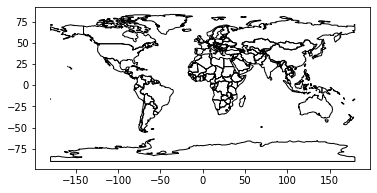

In [8]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.plot(color='none', # fill color
           edgecolor='black') # edge color
plt.show()

Let's see if we can overlay our points onto the map.

In [9]:
# see how the epsg is 4326? the units are DEGREES!
# improper for a distance calculation
world.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

You can use `epsg 3857` instead! A Mercator projection in meters. Look at the difference of how this 'version' of the World looks vs. others.

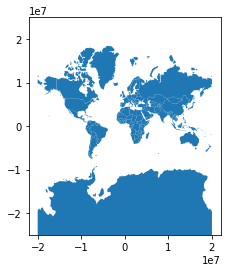

In [10]:
world.to_crs(epsg=3857, inplace=True)
# see the world at the very top? :)
world.plot() 
plt.ylim([-0.25E8,0.25E8])
plt.show()

Let's convert our point data to a shapefile, assign it a CRS (lat/lon), then convert it to meters.

In [11]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(df.longitude, df.latitude)]
crs = {'init': 'epsg:4326'} #http://www.spatialreference.org/ref/epsg/2263/
geo_df = gpd.GeoDataFrame(df, crs=crs, geometry=geometry)

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


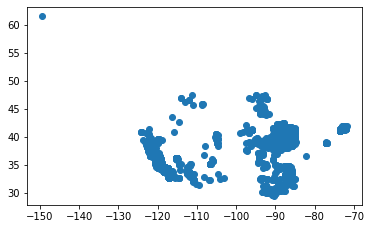

In [12]:
# doesn't this look like alabama? A little nicer.
geo_df.plot()
plt.show()

But as you will see - this crs is in degrees... we need to be in meters before running kMeans.

In [13]:
geo_df.crs

<Geographic 2D CRS: +init=epsg:4326 +type=crs>
Name: WGS 84
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Let's reproject to meters!

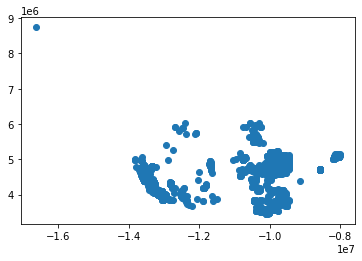

In [14]:
geo_df.to_crs(epsg=3857, inplace=True)
geo_df.plot() # see how the units on the axes is different?
              # it is in meters
plt.show()

Now check your work to get the coordinates. If you look at the geometry column you will notice that your new coordinates in METERS are there. Let's extract them so that it's easy to fit k-means.

In [15]:
geo_df

,index,Unnamed: 0,Address,location,point,latitude,longitude,altitude,geometry
0,0,0,"250 S Colonial Dr Alabaster, AL 35007","250, South Colonial Drive, Alabaster Promenade...","(33.22801276687116, -86.80393934355828, 0.0)",33.228013,-86.803939,0.0,POINT (-9662970.327 3925608.100)
1,1,5,"1407 Quintard Ave. Anniston, AL 36201","1407, Quintard Avenue, Anniston, Calhoun Count...","(33.66260384484535, -85.82695609106196, 0.0)",33.662604,-85.826956,0.0,POINT (-9554213.048 3983587.441)
2,2,6,"1204 N. Brindlee Mountain Pkwy. Arab, AL 35016","North Brindlee Mountain Parkway, Arab, Marshal...","(34.3274117, -86.5031572, 0.0)",34.327412,-86.503157,0.0,POINT (-9629487.412 4072850.604)
3,3,9,"333 S College St Auburn, AL 36830","333, South College Street, Auburn, Lee County,...","(32.600466486800244, -85.48167195523679, 0.0)",32.600466,-85.481672,0.0,POINT (-9515776.194 3842391.858)
4,4,10,"1888 Ogletree Road Auburn, AL 36830","1888, Ogletree Road, Bent Brooke, Auburn, Lee ...","(32.58431374828644, -85.4388022319555, 0.0)",32.584314,-85.438802,0.0,POINT (-9511003.958 3840257.658)
...,...,...,...,...,...,...,...,...,...
2620,2620,3399,"3360 S Mccarran Blvd Reno, NV 89502","3360, South McCarran Boulevard, Donner Springs...","(39.484493180296326, -119.74793599581847, 0.0)",39.484493,-119.747936,0.0,POINT (-13330279.259 4791310.596)
2621,2621,3400,"1550 E Lincoln Way Sparks, NV 89434","1550, East Lincoln Way, Legends at Sparks Mari...","(39.533760459148425, -119.7157426647005, 0.0)",39.533760,-119.715743,0.0,POINT (-13326695.513 4798419.142)
2622,2622,3401,"2878 Vista Blvd Sparks, NV 89434","2878, Vista Boulevard, Sparks, Washoe County, ...","(39.55609547201179, -119.70548522661109, 0.0)",39.556095,-119.705485,0.0,POINT (-13325553.661 4801643.419)
2623,2623,3402,"5151 Sparks Blvd. Sparks, NV 89436","5151, Sparks Boulevard, Sparks, Washoe County,...","(39.58616585973171, -119.72445622755781, 0.0)",39.586166,-119.724456,0.0,POINT (-13327665.503 4805986.013)


Here is how to extract the centroid of any point, line or polygon once it is a geodataframe:
* https://stackoverflow.com/questions/60922709/turn-geometry-column-into-lat-long-columns-in-geodataframe

In [16]:
geo_df['lon_m'] = geo_df.geometry.apply(lambda p: p.x)
geo_df['lat_m'] = geo_df.geometry.apply(lambda p: p.y)
geo_df.head() # check your work

,index,Unnamed: 0,Address,location,point,latitude,longitude,altitude,geometry,lon_m,lat_m
0,0,0,"250 S Colonial Dr Alabaster, AL 35007","250, South Colonial Drive, Alabaster Promenade...","(33.22801276687116, -86.80393934355828, 0.0)",33.228013,-86.803939,0.0,POINT (-9662970.327 3925608.100),-9.662970e+06,3.925608e+06
1,1,5,"1407 Quintard Ave. Anniston, AL 36201","1407, Quintard Avenue, Anniston, Calhoun Count...","(33.66260384484535, -85.82695609106196, 0.0)",33.662604,-85.826956,0.0,POINT (-9554213.048 3983587.441),-9.554213e+06,3.983587e+06
2,2,6,"1204 N. Brindlee Mountain Pkwy. Arab, AL 35016","North Brindlee Mountain Parkway, Arab, Marshal...","(34.3274117, -86.5031572, 0.0)",34.327412,-86.503157,0.0,POINT (-9629487.412 4072850.604),-9.629487e+06,4.072851e+06
3,3,9,"333 S College St Auburn, AL 36830","333, South College Street, Auburn, Lee County,...","(32.600466486800244, -85.48167195523679, 0.0)",32.600466,-85.481672,0.0,POINT (-9515776.194 3842391.858),-9.515776e+06,3.842392e+06
4,4,10,"1888 Ogletree Road Auburn, AL 36830","1888, Ogletree Road, Bent Brooke, Auburn, Lee ...","(32.58431374828644, -85.4388022319555, 0.0)",32.584314,-85.438802,0.0,POINT (-9511003.958 3840257.658),-9.511004e+06,3.840258e+06


OK - you are ready to rock now! Just subset `lat_m` and `lon_m` and you are ready to rock.

# $k=2$

As the analyst, you get to choose what $k$ is - the simplest thing to do is to use $k=2$ but eventually you can use any value and see what you get. Remember, due to the randomness of the algorithm, you may end up with different results if you run it 10 times and plot the answer (more on that soon).

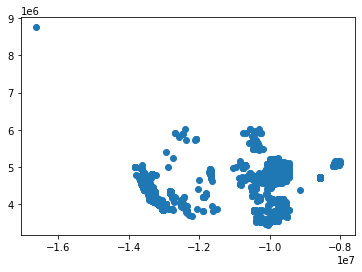

In [17]:
from sklearn.cluster import KMeans
import numpy as np
X = geo_df[['lon_m', 'lat_m']]
plt.scatter(x=X['lon_m'], y=X['lat_m'])
plt.show()

In [18]:
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)

# this is the label of the 'centroid' that corresponds to each point
print('labelAssignment to Stores:', kmeans.labels_)
print('geogCoords of the k facilities:', kmeans.cluster_centers_)
print('SSE (intertia) of each cluster:', kmeans.inertia_)

labelAssignment to Stores: [1 1 1 ... 0 0 0]
geogCoords of the k facilities: [[-13086793.59657524   4240060.20094245]
 [ -9709845.72430396   4731824.46291918]]
SSE (intertia) of each cluster: 1526926953588091.5


We can add these labels back to the geodataframe to 'color by group' (or category) and make a nice map to check our work.

In [19]:
geo_df['clusterLabel'] = kmeans.labels_

In [20]:
# convert the two points to geodataframes and add them to the plot
theWarehouses = kmeans.cluster_centers_
theWarehouses = pd.DataFrame(theWarehouses)
theWarehouses

,0,1
0,-1.308679e+07,4.240060e+06
1,-9.709846e+06,4.731824e+06


In [21]:
# rename columns for ease
theWarehouses.rename(columns={0:'lon_m', 1:'lat_m'}, inplace=True)

We will recycle some code from above for clarity.

In [22]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(theWarehouses['lon_m'], theWarehouses['lat_m'])]
crs = {'init': 'epsg:3857'} #our data is already in meters!
theWarehouses = gpd.GeoDataFrame(theWarehouses, crs=crs, geometry=geometry)

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


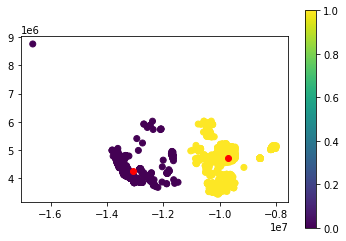

In [23]:
ax = geo_df.plot(column='clusterLabel', legend=True)
theWarehouses.plot(ax=ax, color='red')
plt.show()

## Make a nice map in `folium` of your results

The HTML map really looks much nicer than the static plt maps, but the downside is that these maps can be tough to show in a meeting.

In [24]:
# convert theWareshouses back to latlon
theWarehouses.to_crs(epsg='4326', inplace=True)
theWarehouses['lon'] = theWarehouses.geometry.x
theWarehouses['lat'] = theWarehouses.geometry.y

In [25]:
# on your own!
import folium as folium
map1 = folium.Map(
    location=[30, -86], # lat lon of alabama!
    tiles='cartodbpositron',
    zoom_start=3,
)
geo_df.apply(lambda row:folium.CircleMarker(location=[row["latitude"], row["longitude"]]).add_to(map1), axis=1)
# green dots for the shopping cart
theWarehouses.apply(lambda row:folium.Marker(location=[row["lat"], row["lon"]], icon=folium.Icon(color="green", icon="shopping-cart")).add_to(map1), axis=1)
map1

Output hidden; open in https://colab.research.google.com to view.

# $k=5$
It is ALL the same code - but I made `n_clusters=5`

In [26]:
kmeans = KMeans(n_clusters=5, random_state=0).fit(X)

# this is the label of the 'centroid' that corresponds to each point
print('labelAssignment to Stores:', kmeans.labels_)
print('geogCoords of the k facilities:', kmeans.cluster_centers_)

labelAssignment to Stores: [3 3 3 ... 1 1 1]
geogCoords of the k facilities: [[ -9972587.93460216   4981145.88192846]
 [-13268322.78159183   4248786.72137145]
 [ -8213197.31758958   5004746.96976333]
 [ -9948433.15111039   3793452.65062612]
 [-12246729.96548115   4199676.43324286]]


We can add these labels back to the geodataframe to 'color by group' (or category) and make a nice map to check our work.

In [27]:
geo_df['clusterLabel'] = kmeans.labels_

In [28]:
# convert the two points to geodataframes and add them to the plot
theWarehouses = kmeans.cluster_centers_
theWarehouses = pd.DataFrame(theWarehouses)
theWarehouses

,0,1
0,-9.972588e+06,4.981146e+06
1,-1.326832e+07,4.248787e+06
2,-8.213197e+06,5.004747e+06
3,-9.948433e+06,3.793453e+06
4,-1.224673e+07,4.199676e+06


In [29]:
# rename columns for ease
theWarehouses.rename(columns={0:'lon_m', 1:'lat_m'}, inplace=True)

We will recycle some code from above for clarity.

In [30]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(theWarehouses['lon_m'], theWarehouses['lat_m'])]
crs = {'init': 'epsg:3857'} #our data is already in meters!
theWarehouses = gpd.GeoDataFrame(theWarehouses, crs=crs, geometry=geometry)

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


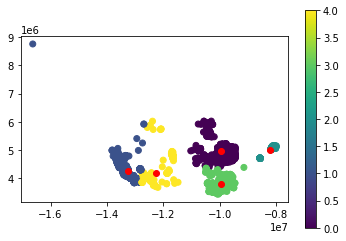

In [31]:
# this map is OK when clusters are small
ax = geo_df.plot(column='clusterLabel', legend=True)
theWarehouses.plot(ax=ax, color='red')
plt.show()

This legend is OK - but it really shouldn't be continuous... should be discrete entries!

What do you see? Some clusters are very big and some are very small. Some are quite round and some are quite elongated.

## Make a nice map in `folium` of your results

The HTML map really looks much nicer than the static plt maps, but the downside is that these maps can be tough to show in a meeting.

In [32]:
# convert theWareshouses back to latlon
theWarehouses.to_crs(epsg='4326', inplace=True)
theWarehouses['lon'] = theWarehouses.geometry.x
theWarehouses['lat'] = theWarehouses.geometry.y

In [33]:
# on your own!
import folium as folium
map1 = folium.Map(
    location=[30, -86], # lat lon of alabama!
    tiles='cartodbpositron',
    zoom_start=3,
)
geo_df.apply(lambda row:folium.CircleMarker(location=[row["latitude"], row["longitude"]]).add_to(map1), axis=1)
# green dots for the shopping cart
theWarehouses.apply(lambda row:folium.Marker(location=[row["lat"], row["lon"]], icon=folium.Icon(color="green", icon="shopping-cart")).add_to(map1), axis=1)
map1

Output hidden; open in https://colab.research.google.com to view.

# $k=20$
It is ALL the same code - but I made `n_clusters=5`

In [34]:
kmeans = KMeans(n_clusters=20, random_state=0).fit(X)

# this is the label of the 'centroid' that corresponds to each point
print('labelAssignment to Stores:', kmeans.labels_)
print('geogCoords of the k facilities:', kmeans.cluster_centers_)

labelAssignment to Stores: [13 13 13 ...  6  6  6]
geogCoords of the k facilities: [[ -9953491.74146016   4930045.85316704]
 [-13326112.12526716   4298157.03128531]
 [ -8113148.98513759   5086176.37693827]
 [-10108991.70790329   3602453.57658296]
 [-12454379.19375901   3935471.76046109]
 [-10392238.89940606   5645924.86905359]
 [-13557816.54375752   4588143.39243281]
 [-13123806.8594905    4004423.43079773]
 [ -9769338.31748211   5135318.29766742]
 [-11687084.18210338   4814697.17755369]
 [-10596843.64236911   4774578.09887956]
 [ -9577318.7881578    4846735.52043295]
 [-12438672.14477345   5751608.19924731]
 [ -9645721.98883051   3938434.40646889]
 [-12816486.89069638   4319283.50093497]
 [-10257978.27717579   4229737.13385394]
 [-16631429.14755549   8759764.95542137]
 [ -8575276.99693966   4710050.06760638]
 [-11830926.38566005   4114634.84241841]
 [-10037973.38469517   4655917.64501659]]


We can add these labels back to the geodataframe to 'color by group' (or category) and make a nice map to check our work.

In [35]:
geo_df['clusterLabel'] = kmeans.labels_

In [36]:
# convert the two points to geodataframes and add them to the plot
theWarehouses = kmeans.cluster_centers_
theWarehouses = pd.DataFrame(theWarehouses)
theWarehouses

,0,1
0,-9.953492e+06,4.930046e+06
1,-1.332611e+07,4.298157e+06
2,-8.113149e+06,5.086176e+06
3,-1.010899e+07,3.602454e+06
4,-1.245438e+07,3.935472e+06
5,-1.039224e+07,5.645925e+06
6,-1.355782e+07,4.588143e+06
7,-1.312381e+07,4.004423e+06
8,-9.769338e+06,5.135318e+06
9,-1.168708e+07,4.814697e+06


In [37]:
# rename columns for ease
theWarehouses.rename(columns={0:'lon_m', 1:'lat_m'}, inplace=True)

We will recycle some code from above for clarity.

In [38]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(theWarehouses['lon_m'], theWarehouses['lat_m'])]
crs = {'init': 'epsg:3857'} #our data is already in meters!
theWarehouses = gpd.GeoDataFrame(theWarehouses, crs=crs, geometry=geometry)

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


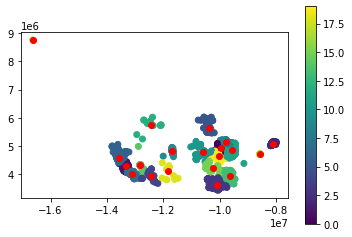

In [39]:
# this map is OK when clusters are small
ax = geo_df.plot(column='clusterLabel', legend=True)
theWarehouses.plot(ax=ax, color='red')
plt.show()

This legend is OK - but it really shouldn't be continuous... should be discrete entries!

What do you see? Some clusters are very big and some are very small. Some are quite round and some are quite elongated.

## Make a nice map in `folium` of your results

The HTML map really looks much nicer than the static plt maps, but the downside is that these maps can be tough to show in a meeting.

In [40]:
# convert theWareshouses back to latlon
theWarehouses.to_crs(epsg='4326', inplace=True)
theWarehouses['lon'] = theWarehouses.geometry.x
theWarehouses['lat'] = theWarehouses.geometry.y

In [41]:
# on your own!
import folium as folium
map1 = folium.Map(
    location=[30, -86], # lat lon of alabama!
    tiles='cartodbpositron',
    zoom_start=3,
)
geo_df.apply(lambda row:folium.CircleMarker(location=[row["latitude"], row["longitude"]]).add_to(map1), axis=1)
# green dots for the shopping cart
theWarehouses.apply(lambda row:folium.Marker(location=[row["lat"], row["lon"]], icon=folium.Icon(color="green", icon="shopping-cart")).add_to(map1), axis=1)
map1

Output hidden; open in https://colab.research.google.com to view.

# k in a for loop
... do you get different results?

This is a beautiful article - you can hack some of the code and see how you can get slightly different results each time you run the model. You will also see the 'elbow method' for selecting the 'optimal' number of records from a 'scree plot' (y = SSE interia vs. X = number of clusters).

From Wikipedia...

<center>

![link text](https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif)

</center>

# Try incorporating a sample weight ($k=5$)
This could be the population of the customer base served at an existing store location. `sample_weight` is the argument and has the same effect of duplicating a row (you can try this!!!)

I could be much more elegant here - but for now, I will just put in a random number - this should cause the locations of the facilities to shift! You can imagine it is the number of deliveries required each week (due to demand).

In [42]:
geo_df['Deliveries'] = np.random.normal(loc=1000, scale=200, size=np.shape(geo_df)[0])
geo_df.head()

,index,Unnamed: 0,Address,location,point,latitude,longitude,altitude,geometry,lon_m,lat_m,clusterLabel,Deliveries
0,0,0,"250 S Colonial Dr Alabaster, AL 35007","250, South Colonial Drive, Alabaster Promenade...","(33.22801276687116, -86.80393934355828, 0.0)",33.228013,-86.803939,0.0,POINT (-9662970.327 3925608.100),-9.662970e+06,3.925608e+06,13,879.873008
1,1,5,"1407 Quintard Ave. Anniston, AL 36201","1407, Quintard Avenue, Anniston, Calhoun Count...","(33.66260384484535, -85.82695609106196, 0.0)",33.662604,-85.826956,0.0,POINT (-9554213.048 3983587.441),-9.554213e+06,3.983587e+06,13,846.084164
2,2,6,"1204 N. Brindlee Mountain Pkwy. Arab, AL 35016","North Brindlee Mountain Parkway, Arab, Marshal...","(34.3274117, -86.5031572, 0.0)",34.327412,-86.503157,0.0,POINT (-9629487.412 4072850.604),-9.629487e+06,4.072851e+06,13,1139.636561
3,3,9,"333 S College St Auburn, AL 36830","333, South College Street, Auburn, Lee County,...","(32.600466486800244, -85.48167195523679, 0.0)",32.600466,-85.481672,0.0,POINT (-9515776.194 3842391.858),-9.515776e+06,3.842392e+06,13,1240.884108
4,4,10,"1888 Ogletree Road Auburn, AL 36830","1888, Ogletree Road, Bent Brooke, Auburn, Lee ...","(32.58431374828644, -85.4388022319555, 0.0)",32.584314,-85.438802,0.0,POINT (-9511003.958 3840257.658),-9.511004e+06,3.840258e+06,13,985.129670


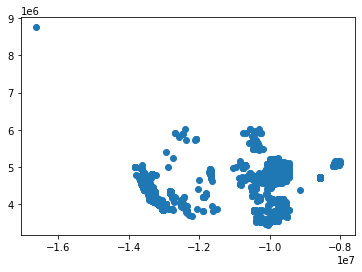

In [43]:
from sklearn.cluster import KMeans
import numpy as np
X = geo_df[['lon_m', 'lat_m', 'Deliveries']]
plt.scatter(x=X['lon_m'], y=X['lat_m'])
plt.show()

In [44]:
kmeans = KMeans(n_clusters=5, random_state=0).fit(X[['lon_m', 'lat_m']], sample_weight=X['Deliveries'])

# this is the label of the 'centroid' that corresponds to each point
print('labelAssignment to Stores:', kmeans.labels_)
print('geogCoords of the k facilities:', kmeans.cluster_centers_)
print('SSE (intertia) of each cluster:', kmeans.inertia_)

labelAssignment to Stores: [3 3 3 ... 1 1 1]
geogCoords of the k facilities: [[ -9969645.529718     4979366.25667188]
 [-13269233.03512421   4248987.30883904]
 [ -8211156.40574163   5006196.60868042]
 [ -9945504.21564639   3796647.92819432]
 [-12248752.02594544   4199815.47196273]]
SSE (intertia) of each cluster: 5.025734436830911e+17


We can add these labels back to the geodataframe to 'color by group' (or category) and make a nice map to check our work.

In [45]:
geo_df['clusterLabel'] = kmeans.labels_

In [46]:
# convert the two points to geodataframes and add them to the plot
theWarehouses = kmeans.cluster_centers_
theWarehouses = pd.DataFrame(theWarehouses)
theWarehouses

,0,1
0,-9.969646e+06,4.979366e+06
1,-1.326923e+07,4.248987e+06
2,-8.211156e+06,5.006197e+06
3,-9.945504e+06,3.796648e+06
4,-1.224875e+07,4.199815e+06


In [47]:
# rename columns for ease
theWarehouses.rename(columns={0:'lon_m', 1:'lat_m'}, inplace=True)

We will recycle some code from above for clarity.

In [48]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(theWarehouses['lon_m'], theWarehouses['lat_m'])]
crs = {'init': 'epsg:3857'} #our data is already in meters!
theWarehouses = gpd.GeoDataFrame(theWarehouses, crs=crs, geometry=geometry)

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


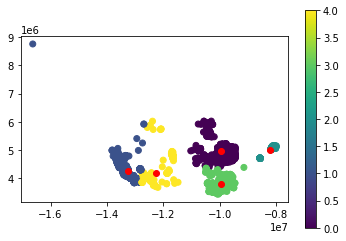

In [49]:
ax = geo_df.plot(column='clusterLabel', legend=True)
theWarehouses.plot(ax=ax, color='red')
plt.show()

This plot is way different than the k=5 above... all due to the weighting!

If you make mean 10000 and the sd 3000, it will be a huge difference!

# [optional] Scree Plot for Optimal Clusters
You probably learned about this in predictive modeling - give this a try!
* https://predictivehacks.com/k-means-elbow-method-code-for-python/

In [50]:
X

,lon_m,lat_m,Deliveries
0,-9.662970e+06,3.925608e+06,879.873008
1,-9.554213e+06,3.983587e+06,846.084164
2,-9.629487e+06,4.072851e+06,1139.636561
3,-9.515776e+06,3.842392e+06,1240.884108
4,-9.511004e+06,3.840258e+06,985.129670
...,...,...,...
2620,-1.333028e+07,4.791311e+06,1131.339395
2621,-1.332670e+07,4.798419e+06,1041.844711
2622,-1.332555e+07,4.801643e+06,1079.092415
2623,-1.332767e+07,4.805986e+06,798.287637


In [51]:
distortions = []
K = range(1,100) # from 1 to 100 clusters
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=0).fit(X[['lon_m', 'lat_m']])
    distortions.append(kmeanModel.inertia_)

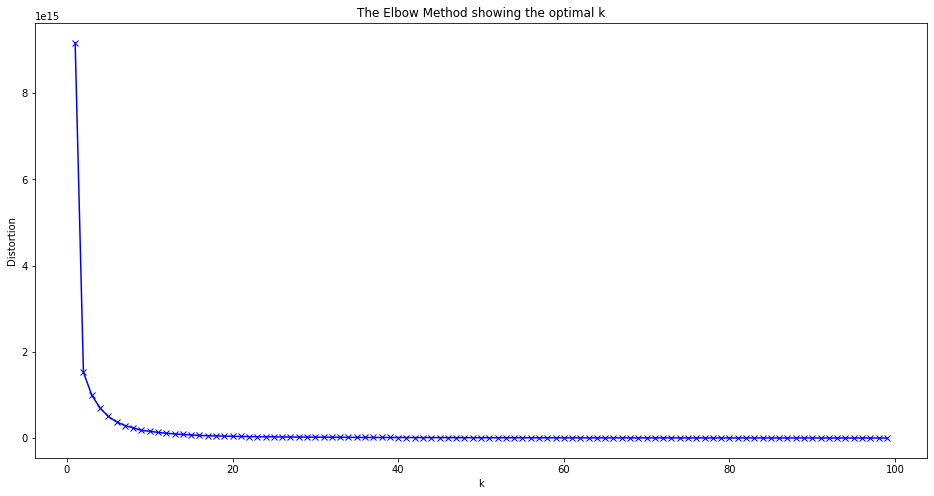

In [52]:
# now plot the result!
plt.figure(figsize=(16,8))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

Where would you add a vertical red line? Somewhere around 8 or 10 clusters? Then within each major clustering, perhaps you would like to re-run again.

# [optional] Stamen Terrain as basemap

Beatufiul 3D markers with terrain as the background.

In [53]:
map1 = folium.Map(
    location=[30, -86], # lat lon of center?
    tiles='Stamen Terrain',
    zoom_start=3,
)
df.apply(lambda row:folium.Marker(location=[row["latitude"], row["longitude"]],popup="Camp Muir").add_to(map1), axis=1)
map1


Output hidden; open in https://colab.research.google.com to view.

Take a little bit to load, but it is beautfiul for your audience. On your own, try to add the warehouses here.

# [optional] Constrained k-means
If you want to set an upper limit on the number of entries per cluster - try this!
* https://towardsdatascience.com/advanced-k-means-controlling-groups-sizes-and-selecting-features-a998df7e6745

Be careful with your sample sizes. If you have 1000 rows and say 5 clusters with 20 per group, a lot of data will not join a cluster.